## Mão na massa: avaliando o desempenho das vendas

Vamos aproveitar esse espaço para praticar tudo o que aprendemos durante a aula. Para isso, serão apresentados alguns casos para que você possa aplicar os seus conhecimentos e explorar as suas habilidades. Topa começar a pôr a mão na massa?

Caso TechTaste
Você faz parte de uma empresa de consultoria. Atualmente, seu cliente é um restaurante de delivery chamado TechTaste. Nele, foi introduzido um novo estilo de atendimento ao cliente ─ agora com um chat de inteligência artificial. Para avaliar a eficácia da IA, foram coletadas várias avaliações de clientes que tiveram contato com o novo chat da TechTaste. Uma amostra com 80 avaliações foi separada para a análise. As notas foram dadas dentro de um intervalo de 0 a 100.

A empresa de consultoria precisa fazer diversas análises em relação ao conjunto de avaliações. Na equipe responsável por essa consultoria foi planejado realizar uma análise inicial antes de pensar em explorar mais os valores. A equipe separou algumas etapas para fazer uma análise inicial:

Calcule o desvio padrão amostral das avaliações.
Calcule o erro padrão amostral da média para as avaliações dos clientes.
Utilizando um gráfico de histograma, analise visualmente a distribuição das avaliações dos clientes.
Observe o formato da distribuição gerado no histograma. Ele se assemelha a uma distribuição normal?
Com um nível de confiança de 90%, calcule o intervalo de confiança para a média das avaliações.
A largura do intervalo de confiança seria afetada se o nível de confiança fosse aumentado para 95%?
Com base no que você aprendeu, como você executaria essas atividades?

In [70]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# Conjunto de dados TechTaste
df_techtaste = pd.DataFrame({'avaliacoes': [38, 44, 33, 42, 47, 33, 36, 39, 42, 36, 39, 34, 42, 42, 36, 43, 31, 
                                            35, 36, 41, 42, 30, 25, 38, 47, 36, 32, 45, 44, 45, 37, 48, 37, 36, 
                                            44, 49, 31, 45, 45, 40, 36, 50, 38, 34, 36, 42, 46, 49, 36, 34, 38, 
                                            31, 53, 40, 57, 40, 36, 42, 26, 50, 32, 43, 35, 37, 42, 30, 36, 43, 
                                            40, 43, 44, 52, 37, 51, 35, 47, 40, 50, 37, 49]})

In [71]:
df_techtaste['avaliacoes'].value_counts()

avaliacoes
36    11
42     8
37     5
40     5
38     4
44     4
43     4
45     4
47     3
34     3
31     3
35     3
49     3
50     3
33     2
39     2
30     2
32     2
41     1
25     1
48     1
46     1
53     1
57     1
26     1
52     1
51     1
Name: count, dtype: int64

In [72]:
#Calcule o desvio padrão amostral das avaliações.

print(f'O desvio padrão é: {df_techtaste['avaliacoes'].std()}')

O desvio padrão é: 6.421827887581659


In [73]:
#Calcule o erro padrão amostral da média para as avaliações dos clientes.

print(f'O erro padrão é: {stats.sem(df_techtaste['avaliacoes'])}')

O erro padrão é: 0.7179821848218233


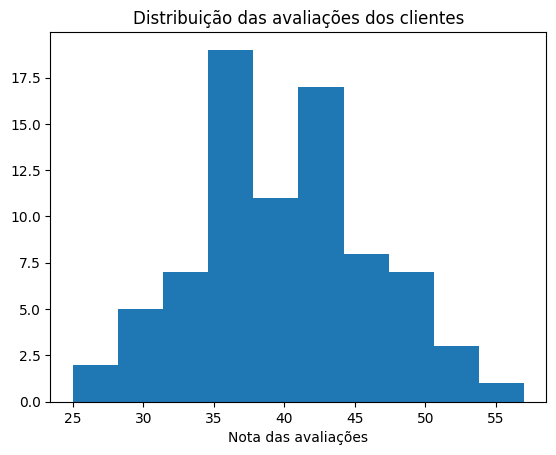

In [ ]:
#Utilizando um gráfico de histograma, analise visualmente a distribuição das avaliações dos clientes.

plt.hist(df_techtaste['avaliacoes'])
plt.title('Distribuição das avaliações dos clientes')
plt.xlabel('Nota das avaliações')
plt.show()

Observe o formato da distribuição gerado no histograma. Ele se assemelha a uma distribuição normal?

Sim, assemelha-se a uma distribuição normal, apesar da irregularidade no meio do gráfico. Observa-se que as pontas direita e esquerda vão aumentando gradativamente ao centro com pico próximo de 35 e 45. Levemente lembra o formato de um sino.

In [75]:
#Com um nível de confiança de 90%, calcule o intervalo de confiança para a média das avaliações.

confianca = 0.90

media = df_techtaste['avaliacoes'].mean()
desvio_padrao_amostra = df_techtaste['avaliacoes'].std()
tamanho_amostra = len(df_techtaste)

intervalo_confianca = stats.norm.interval(
    confianca, #nível de confiança
    loc = media, #onde será adicionada margem de erro (localização)
    scale = desvio_padrao_amostra / np.sqrt(tamanho_amostra) #variabilidade do intervalo - cálculo do erro padrão
)

print('Intervalo de confiança (90%): ', intervalo_confianca)

Intervalo de confiança (90%):  (np.float64(38.84402439920928), np.float64(41.205975600790715))


In [76]:
#A largura do intervalo de confiança seria afetada se o nível de confiança fosse aumentado para 95%?

confianca = 0.95

intervalo_confianca = stats.norm.interval(
    confianca, #nível de confiança
    loc = media, #onde será adicionada margem de erro (localização)
    scale = desvio_padrao_amostra / np.sqrt(tamanho_amostra) #variabilidade do intervalo - cálculo do erro padrão
)

print('Intervalo de confiança (95%): ', intervalo_confianca)

#A largura é afetada levemente, diminuindo casas decimais no mínimo e aumentando casas decimais no máximo

Intervalo de confiança (95%):  (np.float64(38.617780776207844), np.float64(41.43221922379215))


### Extra: incluir 200 avaliações aleatórias e refazer os cálculos

In [ ]:
#função para gerar amostras aleatórias

#passo o data frame a receber novos registros e a quantidade de novas linhas
def cria_novos_registros(data_frame, novas_linhas):
    #define seed do random
    np.random.seed(42)
    #cria dataframe novo em branco
    nova_amostra = pd.DataFrame()
    #preservo quantidade de linhas original do dataframe
    total_linhas_original = len(data_frame)
    #laço para incluir novos registros
    while novas_linhas > 0:
        #este if garante que a quantidade de linhas gerada não será maior que o tamanho inicial do df
        if novas_linhas > total_linhas_original:
            linhas_adicionar = total_linhas_original
        else:
            linhas_adicionar = novas_linhas
        #gerando amostras
        nova_amostra = data_frame.sample(n = linhas_adicionar)
        #concatenando o dataframe novo em outro
        data_frame = pd.concat([data_frame, nova_amostra], ignore_index = True)
        #subtraindo o "contador"
        novas_linhas -= linhas_adicionar
    #retorna data frame atualizado
    return data_frame

In [78]:
df_techtaste = cria_novos_registros(df_techtaste, 200)

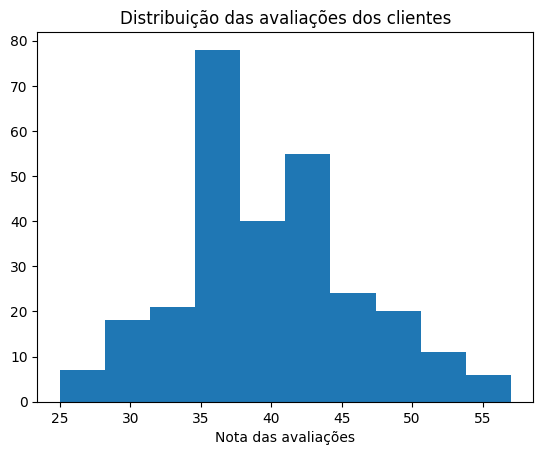

In [83]:
#Utilizando um gráfico de histograma, analise visualmente a distribuição das avaliações dos clientes.

plt.hist(df_techtaste['avaliacoes'])
plt.title('Distribuição das avaliações dos clientes')
plt.xlabel('Nota das avaliações')
plt.show()

In [81]:
#Com um nível de confiança de 90%, calcule o intervalo de confiança para a média das avaliações.

confianca = 0.90

media = df_techtaste['avaliacoes'].mean()
desvio_padrao_amostra = df_techtaste['avaliacoes'].std()
tamanho_amostra = len(df_techtaste)

intervalo_confianca = stats.norm.interval(
    confianca, #nível de confiança
    loc = media, #onde será adicionada margem de erro (localização)
    scale = desvio_padrao_amostra / np.sqrt(tamanho_amostra) #variabilidade do intervalo - cálculo do erro padrão
)

print('Intervalo de confiança (90%): ', intervalo_confianca)

Intervalo de confiança (90%):  (np.float64(39.21187440053231), np.float64(40.48098274232483))
